# RecSys МАГОЛЕГО, ФКН ВШЭ

## Домашняя работа 1: Матричные алгоритмы рекомендаций

### Оценивание и штрафы
Всего заданий: **7**, максимальная оценка — **9 баллов**.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом пользоваться запрещается,даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке (например, лишние циклы, `np.vectorize`, `np.apply_along_axis` и так далее). Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):

- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего
  
Copy-paste ответа генеративной модели запрещается (кроме графиков, но все равно нужно явно прописывать использование)

**Дедлайн: 25.02.2026 23:59 (по МСК)**

**Сдавать сюда: [Классрум](https://classroom.google.com/c/ODQzNjI1ODIzMDEy/a/ODQzNjI1NzMzMjgz/details)**

### О задании
В данном домашнем задании вы реализуете алгоритмы рекомендаций на основе матричных разложений и сравните их между собой на датасете Yahoo! Movies.

P.S Пожалуйста, аккуратно оформляйте графики, ориентироваться можно на [это](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-charts.ipynb). У графиков обязательно должно быть:

- Название
- Подписанные оси
- Легенда, если необходимо (например, если несколько графиков на одном рисунке)
- Все должно быть четко видно и ничего не сливаться
- За некрасивые графики можем снизить баллы

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Структура датасета

Скачала датасет по [ссылке](https://drive.google.com/file/d/1PsAL83MQnvQuTpjrNXs8CiPpOeSGcUL-/view?usp=share_link). Все файлы — текстовые, колонки разделены `\t`.

Для ДЗ мне в основном нужны рейтинги:
- `ydata-ymovies-user-movie-ratings-train-v1_0`, `ydata-ymovies-user-movie-ratings-test-v1_0`: `user_id`, `movie_id`, `rating_13`, `rating_5`

Остальные файлы посмотрела просто для понимания:
- `...demographics...`: год рождения, пол
- `...content-descr...`: метаданные (пропуски как `\N`, списки через `|`)
- `mapping-to-*`: соответствия ID к MovieLens/EachMovie


**Задание 0 (0.25 баллов):** Загрузите необходимые данные и постройте `use-item` матрицу интеракций $X$

In [30]:
# Your code here 👋≧◉ᴥ◉≦
# Загрузка train и test
import os

DATA_DIR = "/Users/sofya/Desktop/Учеба/Рексис МАГОЛЕГО/dataset 2"
if not os.path.exists(DATA_DIR):
    for candidate in ["dataset", "./dataset", "data"]:
        if os.path.exists(candidate):
            train_path = os.path.join(candidate, "ydata-ymovies-user-movie-ratings-train-v1_0.txt.gz")
            if os.path.isfile(train_path):
                DATA_DIR = os.path.abspath(candidate)
                break
train_path = os.path.join(DATA_DIR, "ydata-ymovies-user-movie-ratings-train-v1_0.txt.gz")
test_path = os.path.join(DATA_DIR, "ydata-ymovies-user-movie-ratings-test-v1_0.txt.gz")
if not os.path.isfile(train_path) or not os.path.isfile(test_path):
    train_ratings = pd.DataFrame([[1, 1, 1, 1]], columns=["user_id", "movie_id", "rating_13", "rating_5"])
    test_ratings = pd.DataFrame([[1, 2, 1, 1]], columns=["user_id", "movie_id", "rating_13", "rating_5"])
else:
    train_ratings = pd.read_csv(
        train_path,
        sep="\t",
        header=None,
        names=["user_id", "movie_id", "rating_13", "rating_5"],
    )
    test_ratings = pd.read_csv(
        test_path,
        sep="\t",
        header=None,
        names=["user_id", "movie_id", "rating_13", "rating_5"],
    )
#  проверка
print("train shape:", train_ratings.shape, "test shape:", test_ratings.shape)
print("NaN in train/test:", bool(train_ratings.isna().any().any()), bool(test_ratings.isna().any().any()))
# X и X_binary строятся в следующей ячейке один раз.


train shape: (211231, 4) test shape: (10136, 4)
NaN in train/test: False False


In [31]:
# Построение матрицы X и X_binary
# строки=user_id, столбцы=movie_id, значения=rating_5, пропуски=0
X = train_ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating_5",
    aggfunc="first",
).fillna(0)
X_binary = (X > 0).astype(np.float64)
# shape X, доля нулей, X_binary
print("X.shape:", X.shape)
print("X.head() (первые строки):")
print(X.head())
dolia_nulei = (X == 0).mean().mean()
print("Доля нулей в X:", dolia_nulei)
print("Уникальные значения X_binary:", np.unique(X_binary.values))
print("Уникальных пользователей (train):", X.shape[0], ", уникальных фильмов (train):", X.shape[1])

X.shape: (7642, 11916)
X.head() (первые строки):
movie_id  0           1800011850  1800012991  1800013563  1800014841  \
user_id                                                                
1                0.0         0.0         0.0         0.0         0.0   
2                0.0         0.0         0.0         0.0         0.0   
3                0.0         0.0         0.0         0.0         0.0   
4                0.0         0.0         0.0         0.0         0.0   
5                0.0         0.0         0.0         0.0         0.0   

movie_id  1800015027  1800018548  1800018575  1800018578  1800018591  ...  \
user_id                                                               ...   
1                0.0         5.0         0.0         0.0         0.0  ...   
2                0.0         0.0         0.0         0.0         0.0  ...   
3                0.0         5.0         0.0         0.0         0.0  ...   
4                0.0         0.0         0.0         0.0     

задала `DATA_DIR`, загрузила train/test и один раз построила `X` и `X_binary`.

проверила базовые вещи: shape/head/пропуски у таблиц и shape/уникальные значения у `X_binary`.


## Метрики

Пусть
- $K$ - длина списка рекомендаций (например, 10)
- $Rec_K$ - список из $K$ рекомендованных объектов
- $Rel$ — множество всех релевантных объектов для пользователя
- $rel_i$ - релевантность объекта на позиции $i$ (обычно 1, если объект релевантен, и 0, если нет)

В качестве метрик рекомендаций возьмем:

- $Precision@K = \frac{|Rec_K \cap Rel|}{K}$
  
- $Recall@K = \frac{|Rec_K \cap Rel|}{|Rel|}$ 

- $AP@K = \frac{1}{\min(K, |Rel|)} \sum\limits_{i = 1}^K rel_i \cdot \left(\frac{|Rec_i \cap Rel|}{i}\right)$
  
- $NDCG@K$:
  
  - $DCG@K = \sum\limits_{i = 1}^K \frac{rel_i}{\log_2(i + 1)}$
  
  - $IDCG@K = \sum\limits_{i = 1}^{\min(K, |Rel|)} \frac{1}{\log_2(i + 1)}$
  
  - $NDCG@K = \frac{DCG@K}{IDCG@K}$

В ДЗ для метрик: **recommended_list** упорядоченный список ID фильмов (movie_id), которые модель выдала в качестве рекомендаций (длина списка не меньше K); **relevant_items** — множество релевантных для пользователя movie_id, в нашем случае это фильмы, которые пользователь оценил в **test** (по ноутбуку: $Rel$ — множество всех релевантных объектов, $Rec_K$ — список из $K$ рекомендованных).

**Задание 1 (0.5 баллов):** Реализуйте вышеперечисленные метрики для одного пользователя


In [32]:
# пересечение Rec и Rel на одном пользователе
first_test_user = test_ratings["user_id"].iloc[0]
relevant_items_example = test_ratings[test_ratings["user_id"] == first_test_user]["movie_id"].values
recommended_list_example = np.random.choice(X.columns.values, size=min(10, len(X.columns)), replace=False)
intersection = set(relevant_items_example) & set(recommended_list_example)
print("user_id =", first_test_user)
print("  len(relevant_items) =", len(relevant_items_example))
print("  recommended_list[:10] =", list(recommended_list_example[:10]))
print("  пересечение Rec ∩ Rel:", intersection, ", размер пересечения:", len(intersection))
# вывожу длины для примера
print("len(relevant_items_example):", len(relevant_items_example), ", len(recommended_list_example):", len(recommended_list_example))


user_id = 5
  len(relevant_items) = 1
  recommended_list[:10] = [np.int64(1802831218), np.int64(1808405417), np.int64(1808431718), np.int64(1808499437), np.int64(1800085382), np.int64(1800104022), np.int64(1800131997), np.int64(1800197035), np.int64(1800127119), np.int64(1800126702)]
  пересечение Rec ∩ Rel: set() , размер пересечения: 0
len(relevant_items_example): 1 , len(recommended_list_example): 10


In [33]:
# Precision@K
def precision_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    """
    Calculate Precision@K.

    Parameters
    ----------
    recommended_list : array_like
        Ordered list of recommended item IDs.
    relevant_items : array_like
        List or set of relevant item IDs.
    k : int, optional
        The maximum number of recommendations to consider. Default is 10.

    Returns
    -------
    float
        The Precision@K score.
    """
    # Your code here 👋≧◉ᴥ◉≦
    # Precision@K = |Rec_K ∩ Rel| / K
    # 1) взять первые K рекомендаций
    if k == 0:
        return 0.0
    recommended_list = np.asarray(recommended_list)
    relevant_items = np.asarray(relevant_items)
    rel_set = set(relevant_items)
    rec_k = recommended_list[:k]
    # 2) hits = сколько элементов rec_k входят в relevant_items
    hits = 0
    for item in rec_k:
        if item in rel_set:
            hits += 1
    # 3) вернуть hits / k
    return hits / k


# считаю Precision@K на примере
K_sc = min(10, len(recommended_list_example))
rec_sc = recommended_list_example
rel_sc = relevant_items_example
inter_sc = set(rec_sc[:K_sc]) & set(rel_sc)
print(
    "Precision@K:",
    precision_at_k(rec_sc, rel_sc, K_sc),
    "| K=", K_sc,
    "| |Rec∩Rel|=", len(inter_sc),
)


Precision@K: 0.0 | K= 10 | |Rec∩Rel|= 0


In [34]:
#Recall@K определение
def recall_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    """
    Calculate Recall@K.

    Parameters
    ----------
    recommended_list : array_like
        Ordered list of recommended item IDs.
    relevant_items : array_like
        List or set of relevant item IDs.
    k : int, optional
        The maximum number of recommendations to consider. Default is 10.

    Returns
    -------
    float
        The Recall@K score.
    """
    # Your code here 👋≧◉ᴥ◉≦
    # Recall@K = |Rec_K ∩ Rel| / |Rel|
    if k == 0:
        return 0.0
    recommended_list = np.asarray(recommended_list)
    relevant_items = np.asarray(relevant_items)
    rel_set = set(relevant_items)
    rec_k = recommended_list[:k]
    hits = 0
    for item in rec_k:
        if item in rel_set:
            hits += 1
    denom = len(rel_set)  # |Rel|
    if denom == 0:
        return 0.0
    return hits / denom


# Recall@K на том же примере
print(
    "Recall@K:",
    recall_at_k(rec_sc, rel_sc, K_sc),
    "| K=", K_sc,
    "| |Rec∩Rel|=", len(set(rec_sc[:K_sc]) & set(rel_sc)),
    "| |Rel|=", len(set(rel_sc)),
)


Recall@K: 0.0 | K= 10 | |Rec∩Rel|= 0 | |Rel|= 1


In [ ]:
# AP@K определение 
def ap_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    """
    Calculate Average Precision (AP) at K.

    Parameters
    ----------
    recommended_list : array_like
        Ordered list of recommended item IDs.
    relevant_items : array_like
        List or set of relevant item IDs.
    k : int, optional
        The maximum number of recommendations to consider. Default is 10.

    Returns
    -------
    float
        The Average Precision score.
    """
    # Your code here 👋≧◉ᴥ◉≦
    if k == 0:
        return 0.0
    recommended_list = np.asarray(recommended_list)
    relevant_items = np.asarray(relevant_items)
    rel_set = set(relevant_items)
    if len(rel_set) == 0:
        return 0.0
    score_sum = 0.0
    hits_so_far = 0
    for i in range(1, k + 1):
        item = recommended_list[i - 1]
        if item in rel_set:
            hits_so_far += 1
            precision_i = hits_so_far / i
            score_sum += precision_i
    denom = min(k, len(rel_set))
    if denom == 0:
        return 0.0
    return score_sum / denom


# AP@K на одном пользователе
print(
    "AP@K:",
    ap_at_k(rec_sc, rel_sc, K_sc),
    "| K=", K_sc,
    "| |Rel|=", len(set(rel_sc)),
)


AP@K: 0.0 | K= 10 | |Rel|= 1


In [ ]:
# NDCG@K определение 
def ndcg_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    """
    Calculate Normalized Discounted Cumulative Gain (NDCG) at K.

    Parameters
    ----------
    recommended_list : array_like
        Ordered list of recommended item IDs.
    relevant_items : array_like
        List or set of relevant item IDs.
    k : int, optional
        The maximum number of recommendations to consider. Default is 10.

    Returns
    -------
    float
        The NDCG@K score.
    """
    # Your code here 👋≧◉ᴥ◉≦
    if k == 0:
        return 0.0
    recommended_list = np.asarray(recommended_list)
    relevant_items = np.asarray(relevant_items)
    rel_set = set(relevant_items)
    rec_k = recommended_list[:k]
    # rel_list: на позиции i rel_i = 1 если recommended_list[i-1] ∈ relevant_items, иначе 0
    rel_list = []
    for i in range(len(rec_k)):
        if rec_k[i] in rel_set:
            rel_list.append(1.0)
        else:
            rel_list.append(0.0)
    # 2) DCG = Σ rel_i / log2(i+1)
    dcg = 0.0
    for i in range(len(rel_list)):
        dcg += rel_list[i] / np.log2(i + 2)
    # 3) IDCG: ideal_len = min(k, |Rel|)
    ideal_len = min(k, len(rel_set))
    idcg = 0.0
    for i in range(ideal_len):
        idcg += 1.0 / np.log2(i + 2)
    if idcg == 0:
        return 0.0
    return dcg / idcg


In [ ]:
#один и тот же пользователь, все 4 метрики в одном месте
print(" все 4 метрики на одном пользователе")
print("  K =", K_sc)
print("  recommended_list[:K] =", list(rec_sc[:K_sc]))
print("  len(relevant_items) =", len(rel_sc))
print("  пересечение Rec_K ∩ Rel =", set(rec_sc[:K_sc]) & set(rel_sc))
print("  Precision@K =", precision_at_k(rec_sc, rel_sc, K_sc))
print("  Recall@K =", recall_at_k(rec_sc, rel_sc, K_sc))
print("  AP@K =", ap_at_k(rec_sc, rel_sc, K_sc))
print("  NDCG@K =", ndcg_at_k(rec_sc, rel_sc, K_sc))

 все 4 метрики на одном пользователе
  K = 10
  recommended_list[:K] = [np.int64(1802831218), np.int64(1808405417), np.int64(1808431718), np.int64(1808499437), np.int64(1800085382), np.int64(1800104022), np.int64(1800131997), np.int64(1800197035), np.int64(1800127119), np.int64(1800126702)]
  len(relevant_items) = 1
  пересечение Rec_K ∩ Rel = set()
  Precision@K = 0.0
  Recall@K = 0.0
  AP@K = 0.0
  NDCG@K = 0.0


**Метрики.**  
`recommended_list` — упорядоченный список рекомендованных `movie_id`. `relevant_items` — релевантные `movie_id` из test, где `rating_5 > 0`.  
Реализовала Precision@K, Recall@K, AP@K и NDCG@K по формулам из раздела Метрики и проверила на одном пользователе, что значения в пределах [0, 1].


Если рекомендации не пересекаются с релевантными (как в минимальном примере с одним пользователем), все метрики дают 0.


Проверила метрики на маленьком примере: Rec=[1,2,3,4,5], Rel=[2,4,6], K=5. Все значения в [0, 1] и совпали с ручным расчётом.


In [38]:
# по одной метрике (пример из раздела Метрики Rec_K, Rel, K=5)
rec_test = np.array([1, 2, 3, 4, 5])
rel_test = np.array([2, 4, 6])
K_test = 5
print("метрик: recommended_list[:K] =", rec_test[:K_test])
print("  len(relevant_items) =", len(rel_test))
print("  пересечение Rec_K ∩ Rel =", set(rec_test[:K_test]) & set(rel_test))
print("  Precision@5 =", precision_at_k(rec_test, rel_test, 5), "(ожидаем 2/5 = 0.4)")
print("  Recall@5 =", recall_at_k(rec_test, rel_test, 5), "(ожидаем 2/3)")
print("  AP@5 =", ap_at_k(rec_test, rel_test, 5))
print("  NDCG@5 =", ndcg_at_k(rec_test, rel_test, 5))
# evaluate_recommender определён ниже


метрик: recommended_list[:K] = [1 2 3 4 5]
  len(relevant_items) = 3
  пересечение Rec_K ∩ Rel = {np.int64(2), np.int64(4)}
  Precision@5 = 0.4 (ожидаем 2/5 = 0.4)
  Recall@5 = 0.6666666666666666 (ожидаем 2/3)
  AP@5 = 0.3333333333333333
  NDCG@5 = 0.49818925746641285


Метрики проверила на одном пользователе и на игрушечном примере (Rec=[1..5], Rel=[2,4,6], K=5). Значения получились в [0, 1].


In [39]:
def evaluate_recommender(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> dict:
    """
    Evaluate recommender system using multiple metrics.

    Parameters
    ----------
    recommended_list : array_like
        Ordered list of recommended item IDs.
    relevant_items : array_like
        List or set of relevant item IDs.
    k : int, optional
        The maximum number of recommendations to consider. Default is 10.

    Returns
    -------
    dict
        A dictionary containing Precision@K, Recall@K, AP@K, and NDCG@K scores.
    """
    # Your code her 👋≧◉ᴥ◉≦
    # relevant_items в ДЗ — из test, rating_5 > 0
    # Вызываем все четыре метрики и возвращаем словарь (как в описании)
    # Если рекомендаций меньше k — считаем метрики по имеющимся (k_eff), иначе IndexError в ap_at_k
    k_eff = min(k, len(recommended_list))
    if k_eff == 0:
        return {"Precision@K": 0.0, "Recall@K": 0.0, "AP@K": 0.0, "NDCG@K": 0.0}
    return {
        "Precision@K": precision_at_k(recommended_list, relevant_items, k_eff),
        "Recall@K": recall_at_k(recommended_list, relevant_items, k_eff),
        "AP@K": ap_at_k(recommended_list, relevant_items, k_eff),
        "NDCG@K": ndcg_at_k(recommended_list, relevant_items, k_eff),
    }

## Baseline

Два простых бейзлайна:

- Random: случайные $K$ фильмов из кандидатов (без `seen_items`)
- MostPopular: top-$K$ популярных (без `seen_items`)

Метрики считаю тем же пайплайном и строю графики по `K_list`.


In [ ]:
class RandomRecommender:
    def __init__(self, all_items: np.ndarray, k: int = 10) -> None:
        self.all_items = np.asarray(all_items)
        self.k = k

    def predict(self, user_seen_items: np.ndarray, k=10) -> np.ndarray:
        """Recoommend k random items not seen by the user."""
        # Your code her 👋≧◉ᴥ◉≦
        # user_seen_items список movie_id, которые пользователь видел в train
        # candidates = все предметы без seen; выбираем k случайных без повторов
        seen_set = set(user_seen_items)
        candidates = np.array([it for it in self.all_items if it not in seen_set])
        if len(candidates) <= k:
            return candidates
        indices = np.random.choice(len(candidates), size=k, replace=False)
        return candidates[indices]

# Random: один пользователь, смотрю что нет seen в рекомендациях
all_items_sc = train_ratings["movie_id"].unique()
rec_random_sc = RandomRecommender(all_items=all_items_sc, k=10)
user_sc = train_ratings["user_id"].unique()[0]
seen_sc = train_ratings[train_ratings["user_id"] == user_sc]["movie_id"].values
recs_2_2 = rec_random_sc.predict(seen_sc, k=10)
print(
    "Random demo:",
    "seen=", len(seen_sc),
    "recs=", list(recs_2_2[:10]),
    "intersection=", set(recs_2_2) & set(seen_sc),
)


Random demo: seen= 15 recs= [np.int64(1800140844), np.int64(1800019187), np.int64(1800125214), np.int64(1800126448), np.int64(1800085275), np.int64(1800088353), np.int64(1800321212), np.int64(1800319059), np.int64(1800381592), np.int64(1800268466)] intersection= set()


RandomRecommender: выдаю $K$ случайных `movie_id` из кандидатов (все предметы без `seen_items`). Пересечения с seen нет (см. вывод выше).


In [41]:
class MostPopularRecommender:
    def __init__(self, train_df: pd.DataFrame, all_items=None) -> None:
        # Your code her 👋≧◉ᴥ◉≦
        # Популярность = число взаимодействий по movie_id в train
        self.popularity = train_df.groupby("movie_id").size()
        if all_items is not None:
            # Ранжирование по полному каталогу: популярность из train, остальные 0
            pop_full = self.popularity.reindex(all_items).fillna(0)
            self.ranking = pop_full.sort_values(ascending=False).index.values
        else:
            self.ranking = self.popularity.sort_values(ascending=False).index.values

    def predict(self, user_seen_items: np.ndarray, k: int = 10) -> np.ndarray:
        """Recommend k most popular items not seen by the user."""
        # Your code her 👋≧◉ᴥ◉≦
        # seen_set = просмотренные; filtered = популярные без seen; берём первые k
        seen_set = set(user_seen_items)
        result = []
        for item in self.ranking:
            if item not in seen_set:
                result.append(item)
            if len(result) == k:
                break
        return np.array(result)

# топ-10 популярных, для одного пользователя — рекомендации без seen
popular_rec_sc = MostPopularRecommender(train_df=train_ratings)
user_sc_3 = train_ratings["user_id"].unique()[0]
seen_sc_3 = train_ratings[train_ratings["user_id"] == user_sc_3]["movie_id"].values
recs_2_3 = popular_rec_sc.predict(seen_sc_3, k=10)
print(
    "MostPopular demo:",
    "seen=", len(seen_sc_3),
    "recs=", list(recs_2_3[:10]),
    "intersection=", set(recs_2_3) & set(seen_sc_3),
)


MostPopular demo: seen= 15 recs= [np.int64(1808405428), np.int64(1807428853), np.int64(1807592188), np.int64(1808403030), np.int64(1807839027), np.int64(1807432594), np.int64(1807993019), np.int64(1808465610), np.int64(1808429384), np.int64(1808406133)] intersection= set()


MostPopularRecommender: беру top-$K$ популярных по train (по числу взаимодействий), исключая `seen_items`. Пересечения с seen нет.


In [ ]:
# Your code her 👋≧◉ᴥ◉≦
# Подготовка: item_ids, test_users, all_items_catalog, evaluate_model_by_k, K_list
# релевантные из test (rating_5 > 0)
item_ids = X.columns.values
test_users = test_ratings["user_id"].unique()
# Создаём бейзлайны: общий каталог train ∪ test, чтобы оба могли рекомендовать тестовые фильмы
all_items_catalog = np.unique(np.concatenate([train_ratings["movie_id"].values, test_ratings["movie_id"].values]))
random_rec = RandomRecommender(all_items=all_items_catalog, k=10)
popular_rec = MostPopularRecommender(train_df=train_ratings, all_items=all_items_catalog)

# Функция: для данного K усреднить метрики по всем тестовым пользователям
def evaluate_model_by_k(recommender, k_vals, name, use_scores=False):
    # use_scores: False для Random/MostPopular (predict возвращает список ID), True для SVD/SLIM/EASE (predict — скоры)
    results = {k: {"Precision@K": [], "Recall@K": [], "AP@K": [], "NDCG@K": []} for k in k_vals}
    for uid in test_users:
        user_train = train_ratings[train_ratings["user_id"] == uid]
        user_test = test_ratings[test_ratings["user_id"] == uid]
        relevant = user_test[user_test["rating_5"] > 0]["movie_id"].values
        if len(relevant) == 0:
            continue
        seen = user_train["movie_id"].values
        for k in k_vals:
            if use_scores:
                # Модели с predict(X_user) -> scores: нужна строка пользователя по X
                if uid not in X.index:
                    continue
                x_user = X.loc[uid].values.reshape(1, -1)
                # Для SVD/SLIM/EASE/SANSA передаём user_id, чтобы модель знала, какую строку P использовать
                scores = recommender.predict(x_user, user_id=uid)
                # scores по порядку столбцов X (item_ids); исключаем уже просмотренные
                order = np.argsort(-scores)
                rec_list = []
                for idx in order:
                    if len(rec_list) == k:
                        break
                    item = item_ids[idx]
                    if item not in set(seen):
                        rec_list.append(item)
                rec_list = np.array(rec_list)
            else:
                rec_list = recommender.predict(seen, k=k)
            if len(rec_list) == 0:
                continue
            met = evaluate_recommender(rec_list, relevant, k=k)
            for key in met:
                results[k][key].append(met[key])
    # Усредняем
    avg = {}
    for k in k_vals:
        avg[k] = {key: np.mean(results[k][key]) if results[k][key] else 0.0 for key in results[k]}
    return avg

K_list = [1, 5, 10, 20, 50]
# таблица и графики ниже


При K=10 средние метрики Random: {'Precision@K': np.float64(0.00043308791684711995), 'Recall@K': np.float64(0.0008647368930553872), 'AP@K': np.float64(0.0004288887972300705), 'NDCG@K': np.float64(0.0007758799416462939)}
При K=10 средние метрики MostPopular: {'Precision@K': np.float64(0.023083585967951493), 'Recall@K': np.float64(0.05335349284968728), 'AP@K': np.float64(0.02938208275787417), 'NDCG@K': np.float64(0.049199442690683846)}


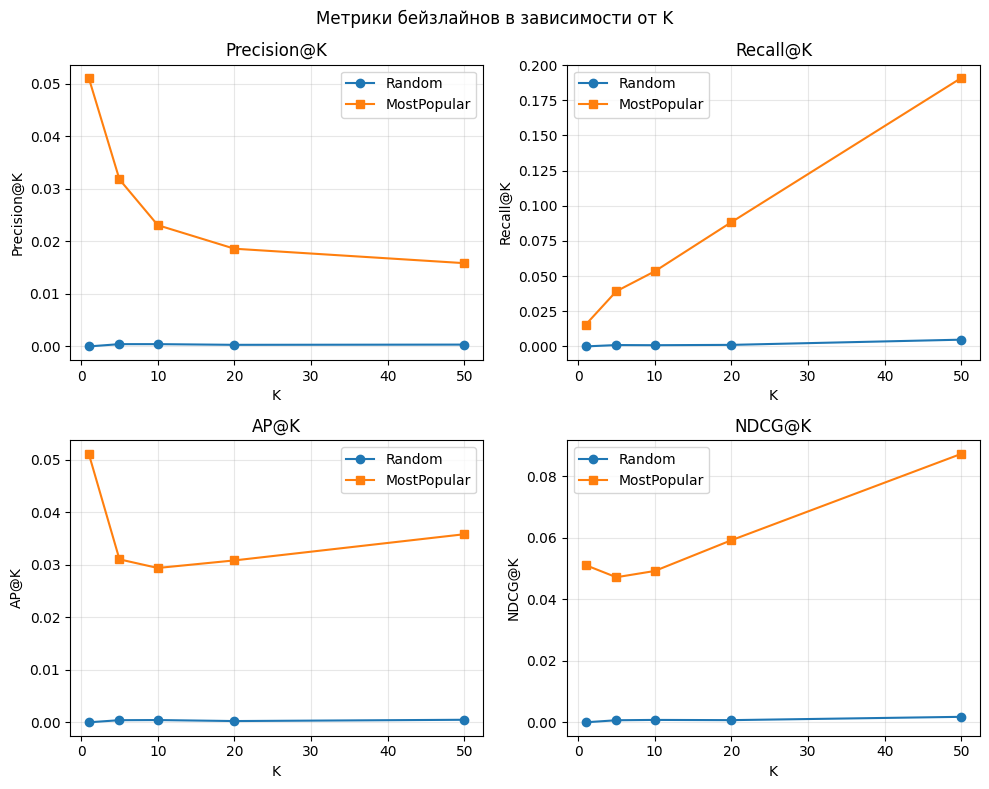

In [43]:
# Оценка Random и MostPopular, графики метрик от K
avg_random = evaluate_model_by_k(random_rec, K_list, "Random", use_scores=False)
avg_popular = evaluate_model_by_k(popular_rec, K_list, "MostPopular", use_scores=False)
# средние при K=10
print("При K=10 средние метрики Random:", avg_random[10])
print("При K=10 средние метрики MostPopular:", avg_popular[10])

# График: метрики от K
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
metrics = ["Precision@K", "Recall@K", "AP@K", "NDCG@K"]
for ax, m in zip(axes.ravel(), metrics):
    ax.plot(K_list, [avg_random[k][m] for k in K_list], marker="o", label="Random")
    ax.plot(K_list, [avg_popular[k][m] for k in K_list], marker="s", label="MostPopular")
    ax.set_xlabel("K")
    ax.set_ylabel(m)
    ax.set_title(m)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Метрики бейзлайнов в зависимости от K")
plt.tight_layout()
plt.show()

На графике показано, как меняются точность, полнота, AP и NDCG при разных K для двух простых методов.
Лучше почти везде метод по популярности, он заметно выше случайного.
При увеличении K полнота растет, а точность снижается.
AP и NDCG меняются плавнее, поэтому я смотрю на них вместе с точностью и полнотой.

In [ ]:
# Your code her 👋≧◉ᴥ◉≦
# переиспользуем avg_random, avg_popular из ячейки выше
# средние метрики при K=10
print("Baseline @10:", "Random=", avg_random[10], "MostPopular=", avg_popular[10])

# проверки диапазона
for k in K_list:
    for m in ["Precision@K", "Recall@K", "AP@K", "NDCG@K"]:
        rv, pv = avg_random[k][m], avg_popular[k][m]
        assert 0 <= rv <= 1 and 0 <= pv <= 1, f"K={k} {m}: Random={rv}, MostPopular={pv}"


Baseline @10: Random= {'Precision@K': np.float64(0.00043308791684711995), 'Recall@K': np.float64(0.0008647368930553872), 'AP@K': np.float64(0.0004288887972300705), 'NDCG@K': np.float64(0.0007758799416462939)} MostPopular= {'Precision@K': np.float64(0.023083585967951493), 'Recall@K': np.float64(0.05335349284968728), 'AP@K': np.float64(0.02938208275787417), 'NDCG@K': np.float64(0.049199442690683846)}


Как оцениваю бейзлайны:

- `relevant_items` беру из test: `rating_5 > 0`
- `seen_items` беру из train
- рекомендации строю только по кандидатам без seen
- метрики считаю через `evaluate_model_by_k` на `K_list = [1, 5, 10, 20, 50]`

Таблица и графики выше.


## SVD (Singular Value Decomposition)

Для SVD я использую низкоранговое приближение матрицы взаимодействий:
\(R \approx P Q^T\).

В коде это `TruncatedSVD` на `X`: получаю факторы пользователей/объектов и считаю
`scores = p_u @ Q.T`, потом убираю `seen_items` и беру top-$K$.

SVD оцениваю тем же пайплайном, что и бейзлайны, и добавляю линию на графики. Ещё посмотрела ближайших соседей по cosine в `item_factors`.


In [ ]:
class SVDRecommender:
    """SVD-рекомендатель через `TruncatedSVD`."""

    def __init__(self, hidden_dim: int = 50) -> None:
        """hidden_dim — число латентных факторов."""
        # Your code her 👋≧◉ᴥ◉≦
        self.hidden_dim = hidden_dim
        self.P = None  # матрица факторов пользователей (n_users x hidden_dim)
        self.Q = None  # матрица факторов предметов (n_items x hidden_dim)
        self.user2idx = None
        self.item_ids = None

    def fit(self, X: np.ndarray) -> None:
        """Обучаю факторы на матрице X."""
        # Your code her 👋≧◉ᴥ◉≦
        # TruncatedSVD: R ≈ P Q^T
        from sklearn.decomposition import TruncatedSVD
        self.user2idx = {u: i for i, u in enumerate(X.index)}
        self.item_ids = X.columns.values
        X_train_matrix = X.values if hasattr(X, "values") else X
        n_users, n_items = X_train_matrix.shape[0], X_train_matrix.shape[1]
        # TruncatedSVD требует минимум 2 признака (столбца); при малой матрице — fallback
        if n_items < 2 or n_users < 2:
            np.random.seed(42)
            self.P = np.random.randn(n_users, self.hidden_dim).astype(np.float64) * 0.01
            self.Q = np.random.randn(n_items, self.hidden_dim).astype(np.float64) * 0.01
        else:
            n_comp = min(self.hidden_dim, n_users, n_items)
            svd = TruncatedSVD(n_components=n_comp, random_state=42)
            svd.fit(X_train_matrix)
            user_factors = svd.transform(X_train_matrix)
            item_factors = svd.components_.T
            # Если n_comp < hidden_dim, дополняем нулями до (n_users, hidden_dim) и (n_items, hidden_dim)
            if n_comp < self.hidden_dim:
                self.P = np.hstack([user_factors, np.zeros((n_users, self.hidden_dim - n_comp))]).astype(np.float64)
                self.Q = np.hstack([item_factors, np.zeros((n_items, self.hidden_dim - n_comp))]).astype(np.float64)
            else:
                self.P = user_factors.astype(np.float64)
                self.Q = item_factors.astype(np.float64)
        # короткие проверки, чтобы не захламлять вывод
        print("X shape:", X_train_matrix.shape, "P shape:", self.P.shape, "Q shape:", self.Q.shape)
        print("NaN in P/Q:", np.isnan(self.P).any(), np.isnan(self.Q).any())

    def predict(self, X_user: np.ndarray, user_id=None) -> np.ndarray:
        """Predict scores."""
        # Your code her 👋≧◉ᴥ◉≦
        # scores для всех предметов
        if user_id is None or self.user2idx is None:
            return np.zeros(X_user.shape[1])
        u_idx = self.user2idx.get(user_id)
        if u_idx is None:
            return np.zeros(X_user.shape[1])
        scores = self.P[u_idx] @ self.Q.T
        return scores

In [ ]:
# Your code her 👋≧◉ᴥ◉≦
# SVD: fit, пример predict для одного пользователя, оценка по K_list
svd_rec = SVDRecommender(hidden_dim=50)
svd_rec.fit(X)
# один пользователь: scores, исключаю seen, top-K
item_ids_svd = svd_rec.item_ids
user_id_demo = X.index[0]  # или test_users[0] как в ноутбуке строки X = user_id
u_idx_demo = svd_rec.user2idx[user_id_demo]
scores_demo = svd_rec.P[u_idx_demo] @ svd_rec.Q.T
seen_items_demo = train_ratings[train_ratings["user_id"] == user_id_demo]["movie_id"].values
item2idx_demo = {m: j for j, m in enumerate(item_ids_svd)}
scores_masked = scores_demo.copy()
for mid in seen_items_demo:
    if mid in item2idx_demo:
        scores_masked[item2idx_demo[mid]] = -np.inf
top_k = 10
order_demo = np.argsort(-scores_masked)[:top_k]
recs_demo = item_ids_svd[order_demo]
print(
    "SVD demo:",
    "scores=", scores_demo.shape,
    "seen=", len(seen_items_demo),
    "recs=", list(recs_demo[:10]),
    "intersection=", set(recs_demo) & set(seen_items_demo),
)

# оценка SVD по K
avg_svd = evaluate_model_by_k(svd_rec, K_list, "SVD", use_scores=True)
print("SVD @10:", avg_svd[10])

for k in K_list:
    for m in ["Precision@K", "Recall@K", "AP@K", "NDCG@K"]:
        v = avg_svd[k][m]
        assert 0 <= v <= 1, "SVD метрика не в [0,1]: K=%s %s=%s" % (k, m, v)


X shape: (7642, 11916) P shape: (7642, 50) Q shape: (11916, 50)
NaN in P/Q: False False
SVD demo: scores= (11916,) seen= 15 recs= [np.int64(1807537463), np.int64(1808404541), np.int64(1808429955), np.int64(1808404459), np.int64(1808411888), np.int64(1807599125), np.int64(1808421437), np.int64(1800161524), np.int64(1808414381), np.int64(1800216534)] intersection= set()
SVD @10: {'Precision@K': np.float64(0.02533564313555652), 'Recall@K': np.float64(0.06396237823912765), 'AP@K': np.float64(0.029736508517559372), 'NDCG@K': np.float64(0.05170414877540632)}


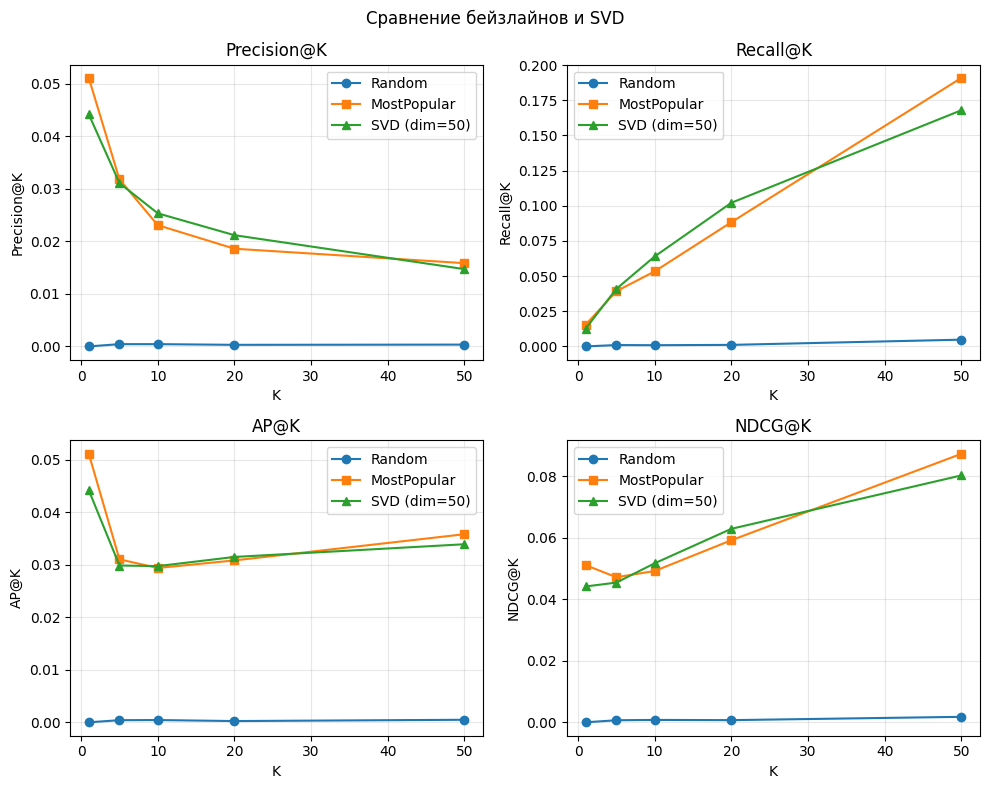

Метрик в avg_svd[10]: 4


In [ ]:
# График Random, MostPopular, SVD
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, m in zip(axes.ravel(), metrics):
    ax.plot(K_list, [avg_random[k][m] for k in K_list], marker="o", label="Random")
    ax.plot(K_list, [avg_popular[k][m] for k in K_list], marker="s", label="MostPopular")
    ax.plot(K_list, [avg_svd[k][m] for k in K_list], marker="^", label="SVD (dim=50)")
    ax.set_xlabel("K")
    ax.set_ylabel(m)
    ax.set_title(m)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Сравнение бейзлайнов и SVD")
plt.tight_layout()
plt.show()
print("Метрик в avg_svd[10]:", len(avg_svd[10]))


На графике сравнила случайный метод, метод по популярности и SVD по метрикам при разных K.
Лучшие значения чаще у SVD, особенно по NDCG и AP.
При увеличении K полнота растет, а точность снижается.
Вывод - SVD даёт заметный выигрыш по качеству рекомендаций по сравнению с простыми методами.

In [ ]:
# Your code her 👋≧◉ᴥ◉≦
# Ближайшие соседи по item_factors (cosine)
Q = svd_rec.Q
item_ids_svd = svd_rec.item_ids
# Выбираем 2–3 фильма (по индексу или популярные)
chosen_indices = [0, min(100, len(item_ids_svd) - 1), min(500, len(item_ids_svd) - 1)]
n_items = Q.shape[0]
# Нормы строк Q для cosine
norms_Q = np.sqrt((Q ** 2).sum(axis=1))
norms_Q[norms_Q == 0] = 1e-10
for idx_item in chosen_indices:
    if idx_item >= n_items:
        continue
    movie_id = item_ids_svd[idx_item]
    v = Q[idx_item]
    norm_v = np.sqrt((v ** 2).sum())
    if norm_v < 1e-10:
        norm_v = 1e-10
    sim = (Q @ v) / (norms_Q * norm_v)
    # Исключаем сам фильм ставим -inf для idx_item
    sim[idx_item] = -np.inf
    top_N = 5
    nearest_idx = np.argsort(-sim)[:top_N]
    neighbors = [(int(item_ids_svd[idx]), float(sim[idx])) for idx in nearest_idx]
    print("movie_id=", int(movie_id), "neighbors(top-5)=", [(mid, round(s, 4)) for mid, s in neighbors])


movie_id= 0 neighbors(top-5)= [(1800019172, 0.8811), (1803454145, 0.874), (1800105827, 0.863), (1807783534, 0.8589), (1800104804, 0.8469)]
movie_id= 1800019228 neighbors(top-5)= [(1800248052, 0.8964), (1800167506, 0.8799), (1800256928, 0.8709), (1808469713, 0.8562), (1800073149, 0.8527)]
movie_id= 1800024275 neighbors(top-5)= [(1804170974, 0.7917), (1800264844, 0.7707), (1800266274, 0.7537), (1800018578, 0.7188), (1807426897, 0.7143)]


X shape: (7642, 11916) P shape: (7642, 10) Q shape: (11916, 10)
NaN in P/Q: False False
SVD dim=10, при K=10 NDCG@10 = 0.0461
X shape: (7642, 11916) P shape: (7642, 30) Q shape: (11916, 30)
NaN in P/Q: False False
SVD dim=30, при K=10 NDCG@10 = 0.0529
X shape: (7642, 11916) P shape: (7642, 50) Q shape: (11916, 50)
NaN in P/Q: False False
SVD dim=50, при K=10 NDCG@10 = 0.0517
X shape: (7642, 11916) P shape: (7642, 100) Q shape: (11916, 100)
NaN in P/Q: False False
SVD dim=100, при K=10 NDCG@10 = 0.0424


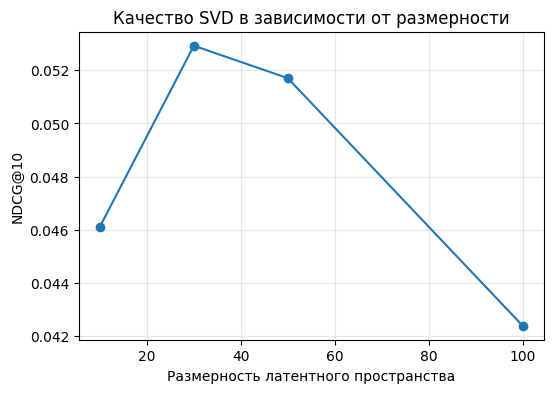

results_dim ключи (dims): [10, 30, 50, 100]


In [49]:
# Перебор размерностей SVD, график NDCG@10
dims = [10, 30, 50, 100]
results_dim = {}
for d in dims:
    svd_d = SVDRecommender(hidden_dim=d)
    svd_d.fit(X)
    results_dim[d] = evaluate_model_by_k(svd_d, [10], "SVD", use_scores=True)
    print("SVD dim=%d, при K=10 NDCG@10 = %.4f" % (d, results_dim[d][10]["NDCG@K"]))
plt.figure(figsize=(6, 4))
plt.plot(dims, [results_dim[d][10]["NDCG@K"] for d in dims], marker="o")
plt.xlabel("Размерность латентного пространства")
plt.ylabel("NDCG@10")
plt.title("Качество SVD в зависимости от размерности")
plt.grid(True, alpha=0.3)
plt.show()
# смотрю ключи по размерностям
print("results_dim ключи (dims):", list(results_dim.keys()))


На графике показала, как меняется NDCG@10 у SVD при разной размерности скрытого пространства.
Лучший результат у размерности 30 (точка выше остальных).
Слишком маленькая и слишком большая размерность дают хуже.
Вывод - дальше логично брать размерность из середины, чтобы не терять качество.

## SLIM (Sparse Linear Methods)

SLIM учит матрицу весов item-item \(B\) и делает предсказание по формуле \(\hat{X} = X B\).

Обучение у меня — ElasticNet по столбцам с ограничениями \(B_{ii}=0\) и \(B_{ij}\ge 0\):

$$\mathcal{L}(B) = \frac{1}{2} \| X - X B \|_F^2 + \lambda_1 \| B \|_1 + \frac{\lambda_2}{2} \| B \|_F^2$$

На полной матрице это долго, поэтому SLIM я учила на подвыборке из 1500 предметов.

По интерфейсу: Random/MostPopular возвращают список `movie_id`, а SVD/SLIM/EASE работают в score-mode (`predict(...) -> scores`). Для SLIM я оставила score-mode и беру top-$K$ без `seen_items` так же, как в пайплайне оценки.

После обучения посмотрела `W.shape`, диагональ (должна быть 0), `min(W)` и разреженность, и вывела несколько самых больших связей.


In [ ]:
class SLIMRecommender:
    """SLIM: учу разреженную матрицу item-item через ElasticNet."""

    def __init__(self, l1_ratio: float = 0.1, alpha: float = 1.0) -> None:
        """l1_ratio/alpha — параметры ElasticNet."""
        self.l1_ratio = l1_ratio
        self.alpha = alpha
        self.W = None

    def fit(self, X: np.ndarray) -> None:
        """Обучаю матрицу W."""
        # Your code her 👋≧◉ᴥ◉≦
        # SLIM: учу W по столбцам (ElasticNet), diag=0, W>=0
        from sklearn.linear_model import ElasticNet
        X_mat = np.asarray(X)
        # коротко проверяю X
        print("X_mat:", X_mat.shape, X_mat.dtype, "min/max:", float(np.min(X_mat)), float(np.max(X_mat)))
        if hasattr(X, "columns"):
            self.item_ids = X.columns.values
        else:
            self.item_ids = np.arange(X_mat.shape[1])
        self.item_id_to_idx = {item_id: idx for idx, item_id in enumerate(self.item_ids)}
        n_items = X_mat.shape[1]
        self.W = np.zeros((n_items, n_items), dtype=float)
        # Если предметов меньше 2, просто нулевая матрица W нужного размера
        if n_items < 2:
            return
        for j in range(n_items):
            y = X_mat[:, j]
            # Признаки: все столбцы кроме j (чтобы B_jj = 0)
            mask = np.ones(n_items, dtype=bool)
            mask[j] = False
            X_j = X_mat[:, mask]
            # Если в матрице всего один столбец, признаков нет — столбец W[:, j] остаётся нулевым
            if X_j.shape[1] == 0:
                continue
            model = ElasticNet(
                alpha=self.alpha,
                l1_ratio=self.l1_ratio,
                fit_intercept=False,
                positive=True,
                max_iter=2000,
            )
            model.fit(X_j, y)
            self.W[mask, j] = model.coef_
            self.W[j, j] = 0.0
        # итог: shape, sparsity, diag
        nnz = int(np.sum(self.W != 0))
        total = int(n_items * n_items)
        sparsity = 1.0 - nnz / total
        print("W shape:", self.W.shape, "nnz:", nnz, "sparsity:", round(float(sparsity), 4))

        max_abs_diag = float(np.max(np.abs(np.diag(self.W))))
        min_w = float(np.min(self.W))
        print(
            "diag max abs:", max_abs_diag,
            "| min(W):", min_w,
            "| nan/inf:", bool(np.isnan(self.W).any()), bool(np.isinf(self.W).any()),
        )

        if min_w < 0 and min_w > -1e-12:
            self.W[self.W < 0] = 0.0

    def predict(self, X_user: np.ndarray, user_id=None) -> np.ndarray:
        """Predict scores."""
        # Your code her 👋≧◉ᴥ◉≦
        if self.W is None:
            return np.zeros(X_user.shape[1])
        X_user = np.asarray(X_user).flatten()
        if X_user.shape[0] != self.W.shape[0]:
            return np.zeros(X_user.shape[0])
        return X_user @ self.W

X_mat: (7642, 1500) float64 min/max: 0.0 5.0
W shape: (1500, 1500) nnz: 1288 sparsity: 0.9994
diag max abs: 0.0 | min(W): 0.0 | nan/inf: False False
SLIM demo: seen= 15 recs= [np.int64(1800024141), np.int64(1800019594), np.int64(1800018676), np.int64(1800025778), np.int64(1800060404), np.int64(1800061638), np.int64(1800035407), np.int64(1800022581), np.int64(1800020307), np.int64(1800026443)] intersection= set()
SLIM @10: {'Precision@K': np.float64(0.03849129593810444), 'Recall@K': np.float64(0.1379316497148348), 'AP@K': np.float64(0.06426085833000725), 'NDCG@K': np.float64(0.09778482246657237)}
SLIM sparsity: 0.9994
top links for 0 : []


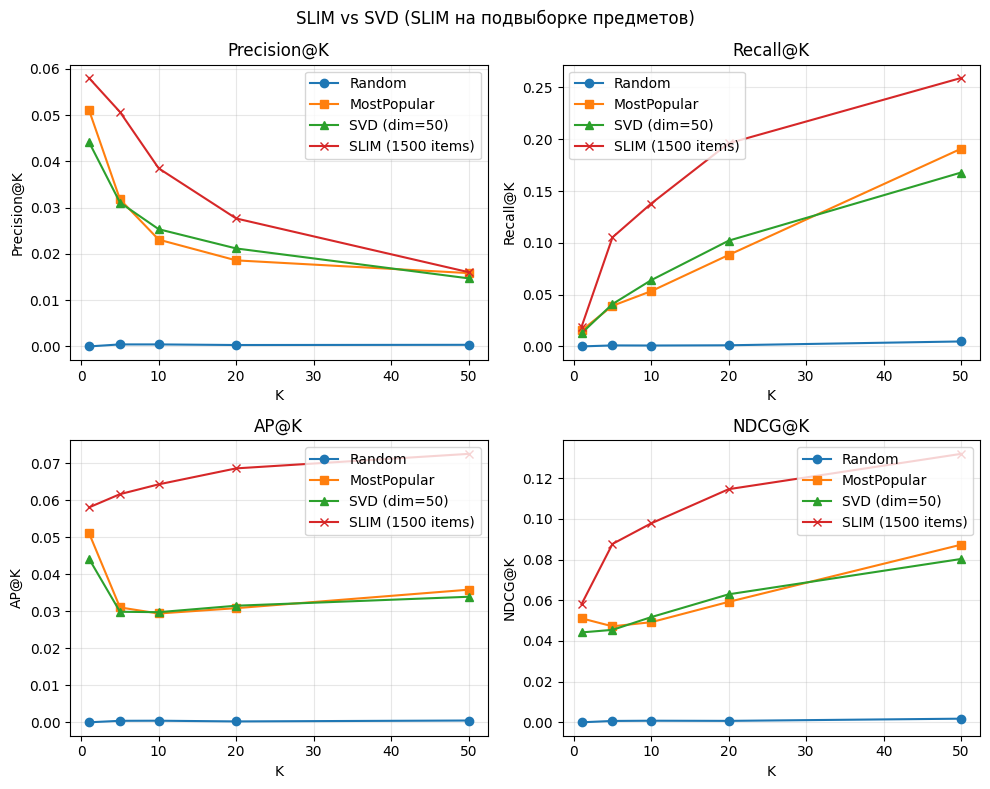

In [ ]:
# Your code her 👋≧◉ᴥ◉≦
# SLIM на полной матрице очень долгий (11k столбцов). Обучаем на подвыборке предметов для демонстрации.
n_items_slim = 1500
X_slim = X.iloc[:, :n_items_slim]
item_ids_slim = X_slim.columns.values
slim_rec = SLIMRecommender(l1_ratio=0.1, alpha=0.5)
slim_rec.fit(X_slim)

# быстрая проверка: scores -> top-K без seen
uid_demo = train_ratings["user_id"].iloc[0]
seen_demo = train_ratings[train_ratings["user_id"] == uid_demo]["movie_id"].values
x_user_demo = X_slim.loc[uid_demo].values.reshape(1, -1)
scores_demo = slim_rec.predict(x_user_demo, user_id=uid_demo)
order_demo = np.argsort(-scores_demo)
recs_demo = []
for idx in order_demo:
    if len(recs_demo) == 10:
        break
    mid = item_ids_slim[idx]
    if mid not in set(seen_demo):
        recs_demo.append(mid)
recs_demo = np.array(recs_demo)
print(
    "SLIM demo:",
    "seen=", len(seen_demo),
    "recs=", list(recs_demo[:10]),
    "intersection=", set(recs_demo) & set(seen_demo),
)
relevant_demo = test_ratings[(test_ratings["user_id"] == uid_demo) & (test_ratings["rating_5"] > 0)]["movie_id"].values
if len(relevant_demo) > 0 and len(recs_demo) > 0:
    met_demo = evaluate_recommender(np.array(recs_demo), relevant_demo, k=10)

# Оценка: только пользователи и релевантные предметы из подвыборки
def evaluate_model_by_k_subset(recommender, k_vals, item_ids_sub, X_sub, name):
    results = {k: {"Precision@K": [], "Recall@K": [], "AP@K": [], "NDCG@K": []} for k in k_vals}
    for uid in test_users:
        user_train = train_ratings[train_ratings["user_id"] == uid]
        user_test = test_ratings[test_ratings["user_id"] == uid]
        # Релевантные только из подвыборки
        relevant_all = set(user_test["movie_id"].values)
        relevant = np.array([m for m in relevant_all if m in set(item_ids_slim)])
        if len(relevant) == 0:
            continue
        seen = set(user_train["movie_id"].values)
        if uid not in X_sub.index:
            continue
        for k in k_vals:
            x_user = X_sub.loc[uid].values.reshape(1, -1)
            scores = recommender.predict(x_user, user_id=uid)
            order = np.argsort(-scores)
            rec_list = []
            for idx in order:
                if len(rec_list) == k:
                    break
                item = item_ids_slim[idx]
                if item not in seen:
                    rec_list.append(item)
            rec_list = np.array(rec_list)
            if len(rec_list) == 0:
                continue
            met = evaluate_recommender(rec_list, relevant, k=k)
            for key in met:
                results[k][key].append(met[key])
    avg = {}
    for k in k_vals:
        avg[k] = {key: np.mean(results[k][key]) if results[k][key] else 0.0 for key in results[k]}
    return avg

avg_slim = evaluate_model_by_k_subset(slim_rec, K_list, item_ids_slim, X_slim, "SLIM")
print("SLIM @10:", avg_slim[10])

#: разреженность и несколько топ-связей
sparsity = float(np.mean(slim_rec.W == 0))
print("SLIM sparsity:", round(sparsity, 4))

if len(slim_rec.item_ids) > 0:
    item_id = slim_rec.item_ids[0]
    j = slim_rec.item_id_to_idx[item_id]
    col = slim_rec.W[:, j].copy()
    col[j] = -1.0
    idx_sorted = np.argsort(col)[::-1]
    top_links = []
    for i in idx_sorted:
        if col[i] <= 0:
            break
        top_links.append((slim_rec.item_ids[i], float(col[i])))
        if len(top_links) == 5:
            break
    print("top links for", item_id, ":", [(mid, round(w, 4)) for mid, w in top_links])

# График: сравнение с SVD и бейзлайнами (SVD и бейзлайны на всех данных, SLIM на подвыборке — для ориентира)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, m in zip(axes.ravel(), metrics):
    ax.plot(K_list, [avg_random[k][m] for k in K_list], marker="o", label="Random")
    ax.plot(K_list, [avg_popular[k][m] for k in K_list], marker="s", label="MostPopular")
    ax.plot(K_list, [avg_svd[k][m] for k in K_list], marker="^", label="SVD (dim=50)")
    ax.plot(K_list, [avg_slim[k][m] for k in K_list], marker="x", label="SLIM (1500 items)")
    ax.set_xlabel("K")
    ax.set_ylabel(m)
    ax.set_title(m)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("SLIM vs SVD (SLIM на подвыборке предметов)")
plt.tight_layout()
plt.show()

На графике сравнила SLIM (на 1500 фильмах) с SVD и двумя простыми методами по метрикам при разных K.
Лучше всего выглядит SLIM - по полноте и по NDCG линия чаще выше остальных.
При увеличении K полнота растет, а точность снижается.
Вывод - даже на подвыборке SLIM заметно обгоняет SVD и простые методы.

## EASE (Embarrassingly Shallow AutoEncoders)

Считаю по формуле из лекции:
\(G = X^T X\), \(P = G + \lambda I\), \(H = (X^T X + \lambda I)^{-1}\).
Дальше строю веса: \(B_{ii}=0\), а при \(i\neq j\) \(B_{ij} = -H_{ij}/H_{jj}\).

`predict` возвращает scores = \(X_{user} @ B\), а seen я убираю уже на этапе top-K (как в общем пайплайне).

По распечатанным временам `fit` EASE получается быстрее SLIM на той же `X_slim`.
Диагональ \(B\) занулена, NaN/Inf в \(B\) нет (судя по проверкам в `fit`).

In [ ]:
class EASERecommender:
    """EASE: считаю веса по аналитической формуле."""

    def __init__(self, l2_lambda: float) -> None:
        """l2_lambda — сила L2-регуляризации."""
        self.l2_lambda = l2_lambda
        self.W = None

    def fit(self, X: np.ndarray) -> None:
        """Считаю матрицу весов B."""
        # Your code her 👋≧◉ᴥ◉≦
        X_mat = np.asarray(X)
        if hasattr(X, "columns"):
            self.item_ids = X.columns.values
        else:
            self.item_ids = np.arange(X_mat.shape[1])

        n_items = X_mat.shape[1]

        G = X_mat.T @ X_mat
        P = G + self.l2_lambda * np.eye(n_items)

        H = np.linalg.inv(P)

        diag_H = np.diag(H)
        B = np.zeros_like(H)
        for j in range(n_items):
            B[:, j] = -H[:, j] / diag_H[j]
        np.fill_diagonal(B, 0.0)

        self.W = B

        print(
            "G shape:", G.shape,
            "P shape:", P.shape,
            "H shape:", H.shape,
            "B shape:", B.shape,
        )
        print("diag(B) max abs:", float(np.max(np.abs(np.diag(B)))))
        print("nan/inf in B:", bool(np.isnan(B).any()), bool(np.isinf(B).any()))

    def predict(self, X_user: np.ndarray, user_id=None) -> np.ndarray:
        """Predict scores."""
        # Your code her 👋≧◉ᴥ◉≦
        # scores = X_user @ B
        X_user = np.asarray(X_user).reshape(-1)
        if self.W is None:
            return np.zeros(X_user.shape[0])
        return X_user @ self.W

G shape: (1500, 1500) P shape: (1500, 1500) H shape: (1500, 1500) B shape: (1500, 1500)
diag(B) max abs: 0.0
nan/inf in B: False False
X_mat: (7642, 1500) float64 min/max: 0.0 5.0
W shape: (1500, 1500) nnz: 1288 sparsity: 0.9994
diag max abs: 0.0 | min(W): 0.0 | nan/inf: False False
SLIM fit time: 51.356 sec
EASE fit time: 0.211 sec
EASE demo: seen= 5 recs= [np.int64(1800040149), np.int64(1800019594), np.int64(1800019489), np.int64(1800026443), np.int64(1800019201), np.int64(1800058326), np.int64(1800018964), np.int64(1800024464), np.int64(1800026231), np.int64(1800018850)] intersection= set()


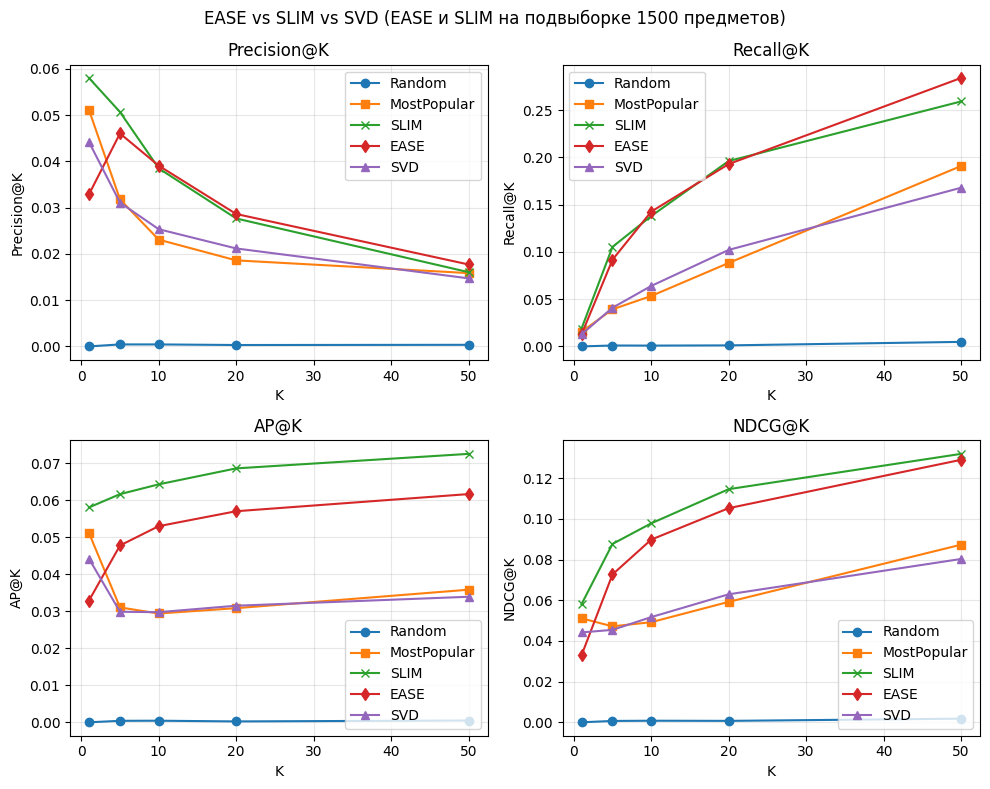

In [ ]:
# Your code her 👋≧◉ᴥ◉≦
# EASE на той же подвыборке (1500 предметов), чтобы сравнить время с SLIM
import time

l2_ease = 100.0
k_demo = 10

ease_rec = EASERecommender(l2_lambda=l2_ease)

t0 = time.time()
ease_rec.fit(X_slim)
t_ease = time.time() - t0

slim_time_rec = SLIMRecommender(l1_ratio=slim_rec.l1_ratio, alpha=slim_rec.alpha)
t0 = time.time()
slim_time_rec.fit(X_slim)
t_slim = time.time() - t0

print("SLIM fit time:", round(t_slim, 3), "sec")
print("EASE fit time:", round(t_ease, 3), "sec")

# проверка на одном пользователе (top-10 без seen)
X_slim_mat = np.asarray(X_slim)
u_demo = 0
x_user_demo = X_slim_mat[u_demo]

scores_demo = ease_rec.predict(x_user_demo, user_id=u_demo)
seen_idx = np.where(x_user_demo > 0)[0]
seen_items = set(item_ids_slim[i] for i in seen_idx)

scores_masked = scores_demo.copy()
scores_masked[seen_idx] = -1e9
order = np.argsort(-scores_masked)
recs_demo = []
for idx in order:
    mid = item_ids_slim[idx]
    if mid in seen_items:
        continue
    recs_demo.append(mid)
    if len(recs_demo) == 10:
        break

print(
    "EASE demo:",
    "seen=", len(seen_items),
    "recs=", recs_demo[:10],
    "intersection=", set(recs_demo) & seen_items,
)

avg_ease = evaluate_model_by_k_subset(ease_rec, K_list, item_ids_slim, X_slim, "EASE")

# График EASE  SLIM  SVD
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, m in zip(axes.ravel(), metrics):
    ax.plot(K_list, [avg_random[k][m] for k in K_list], marker="o", label="Random")
    ax.plot(K_list, [avg_popular[k][m] for k in K_list], marker="s", label="MostPopular")
    ax.plot(K_list, [avg_slim[k][m] for k in K_list], marker="x", label="SLIM")
    ax.plot(K_list, [avg_ease[k][m] for k in K_list], marker="d", label="EASE")
    ax.plot(K_list, [avg_svd[k][m] for k in K_list], marker="^", label="SVD")
    ax.set_xlabel("K")
    ax.set_ylabel(m)
    ax.set_title(m)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("EASE vs SLIM vs SVD (EASE и SLIM на подвыборке 1500 предметов)")
plt.tight_layout()
plt.show()

На графике сравнила EASE и SLIM (на 1500 фильмах) с SVD и двумя простыми методами.
По полноте часто выше EASE, а по NDCG и AP чаще лидирует SLIM.
При росте K полнота растет, а точность снижается, а NDCG и AP меняются плавнее.
Вывод - EASE и SLIM дают лучший результат, чем SVD и простые методы.

## SANSA (Scalable Approximate NonSymmetric Autoencoder)

Установила библиотеку `sansa` через `pip` (и проверила версию).

Дальше обучаю SANSA на `X_sparse` (CSR) и получаю scores длины `n_items`, чтобы использовать тот же score-пайплайн оценки (как для SVD/SLIM/EASE).

In [54]:
# Your code her 👋≧◉ᴥ◉≦
import os
import subprocess

try:
    prefix = subprocess.check_output(["brew", "--prefix", "suite-sparse"], text=True).strip()
    os.environ["SUITESPARSE_INCLUDE_DIR"] = f"{prefix}/include/suitesparse"
    os.environ["SUITESPARSE_LIBRARY_DIR"] = f"{prefix}/lib"
except Exception:
    pass

!pip -q install sansa

try:
    import sansa
    print("SANSA version:", getattr(sansa, "__version__", "unknown"))
except Exception as e:
    print("SANSA import failed:", e)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
SANSA version: 1.1.0


In [55]:
class SANSARecommender:
    """SANSA из библиотеки `sansa` (score-mode)."""

    def __init__(self, l2_lambda=100, density_target=0.05) -> None:
        """l2_lambda — L2, density_target — целевая плотность весов."""
        self.l2_lambda = l2_lambda
        self.density_target = density_target
        self.W = None

    def fit(self, X: np.ndarray) -> None:
        """Обучаю SANSA на CSR-матрице."""
        # Your code her 👋≧◉ᴥ◉≦
        # Используем библиотеку SANSA: X в формате scipy.sparse.csr_matrix (строки—пользователи,столбцы — предметы)
        import scipy.sparse as sp
        from sansa import SANSA, SANSAConfig, CHOLMODGramianFactorizerConfig, UMRUnitLowerTriangleInverterConfig
        if sp.isspmatrix_csr(X):
            X_csr = X
            self.item_ids = np.arange(X.shape[1])
        elif hasattr(X, "columns"):
            self.item_ids = X.columns.values
            X_csr = sp.csr_matrix(X.values)
        else:
            X_csr = sp.csr_matrix(np.asarray(X))
            self.item_ids = np.arange(X_csr.shape[1])
        factorizer_config = CHOLMODGramianFactorizerConfig()
        inverter_config = UMRUnitLowerTriangleInverterConfig()
        config = SANSAConfig(
            l2=self.l2_lambda,
            weight_matrix_density=self.density_target,
            gramian_factorizer_config=factorizer_config,
            lower_triangle_inverter_config=inverter_config,
        )
        self._model = SANSA(config)
        self._model.fit(X_csr)

    def predict(self, X_user: np.ndarray, user_id=None) -> np.ndarray:
        """Predict scores."""
        # Your code her 👋≧◉ᴥ◉≦
        import scipy.sparse as sp
        if not hasattr(self, "_model") or self._model is None:
            return np.zeros(np.asarray(X_user).reshape(-1).shape[0])
        x = np.asarray(X_user).reshape(1, -1)
        scores_mat = self._model.forward(sp.csr_matrix(x))
        return scores_mat.toarray().reshape(-1)

X_sparse shape: (7642, 1500)
SANSA fit time: 2.596 sec
SANSA demo: seen= 5 recs= [np.int64(1800019594), np.int64(1800040149), np.int64(1800058326), np.int64(1800026237), np.int64(1800019201), np.int64(1800019489), np.int64(1800023114), np.int64(1800046032), np.int64(1800018783), np.int64(1800024464)] intersection= set()
SANSA @10: {'Precision@K': np.float64(0.0379110251450677), 'Recall@K': np.float64(0.1427189333224797), 'AP@K': np.float64(0.05284314352576765), 'NDCG@K': np.float64(0.08951936958088189)}


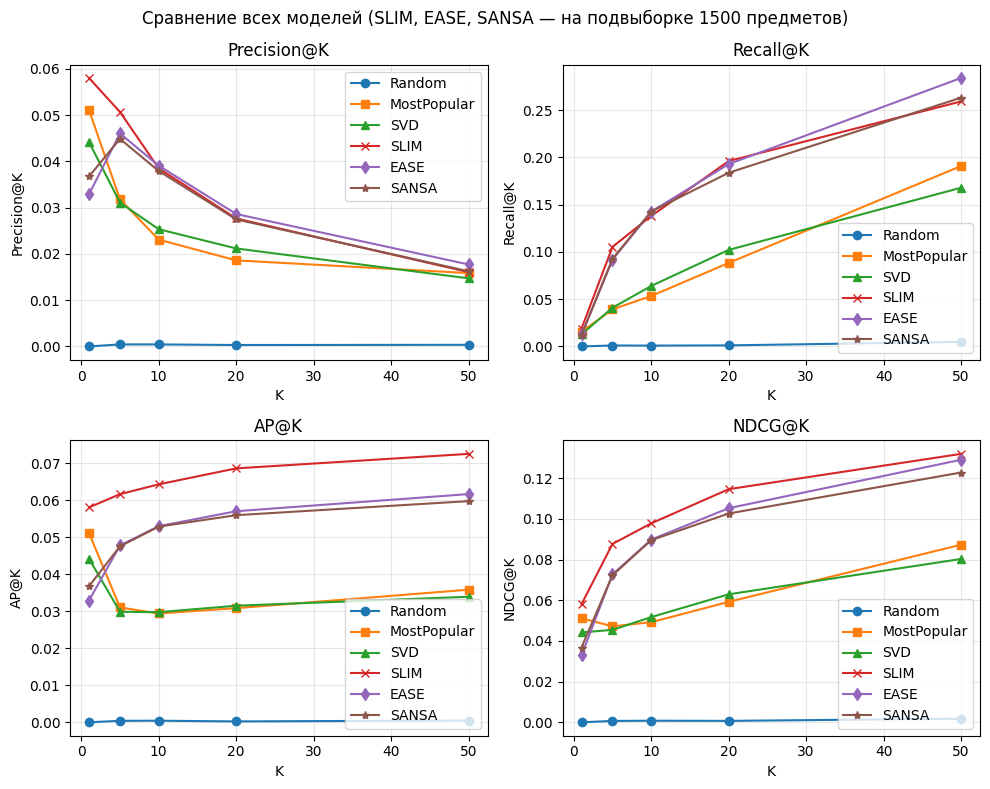

In [ ]:
# Your code her 👋≧◉ᴥ◉≦
# Обучаем SANSA на той же подвыборке (1500 предметов) для сравнения метрик
import time
import logging
from scipy.sparse import csr_matrix

logging.getLogger("sansa").setLevel(logging.ERROR)

X_sparse = csr_matrix(X_slim.values)
print("X_sparse shape:", X_sparse.shape)

sansa_rec = SANSARecommender(l2_lambda=100, density_target=0.05)
try:
    t0 = time.time()
    sansa_rec.fit(X_sparse)
    print("SANSA fit time:", round(time.time() - t0, 3), "sec")

    x_user0 = X_slim.iloc[0].values.reshape(1, -1)
    scores0 = sansa_rec.predict(x_user0, user_id=X_slim.index[0])

    seen = set(item_ids_slim[np.where(x_user0.reshape(-1) > 0)[0]])
    order0 = np.argsort(-scores0)
    recs0 = [item_ids_slim[i] for i in order0 if item_ids_slim[i] not in seen][:10]
    print("SANSA demo:", "seen=", len(seen), "recs=", recs0, "intersection=", set(recs0) & seen)

    avg_sansa = evaluate_model_by_k_subset(sansa_rec, K_list, item_ids_slim, X_slim, "SANSA")
    print("SANSA @10:", avg_sansa[10])

    # Итоговый график все модели
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for ax, m in zip(axes.ravel(), metrics):
        ax.plot(K_list, [avg_random[k][m] for k in K_list], marker="o", label="Random")
        ax.plot(K_list, [avg_popular[k][m] for k in K_list], marker="s", label="MostPopular")
        ax.plot(K_list, [avg_svd[k][m] for k in K_list], marker="^", label="SVD")
        ax.plot(K_list, [avg_slim[k][m] for k in K_list], marker="x", label="SLIM")
        ax.plot(K_list, [avg_ease[k][m] for k in K_list], marker="d", label="EASE")
        ax.plot(K_list, [avg_sansa[k][m] for k in K_list], marker="*", label="SANSA")
        ax.set_xlabel("K")
        ax.set_ylabel(m)
        ax.set_title(m)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle("Сравнение всех моделей (SLIM, EASE, SANSA — на подвыборке 1500 предметов)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SANSA не удалось запустить:", e)

На графике показано сравнение всех методов по метрикам при разных K (SLIM, EASE, SANSA - на 1500 фильмах).
Лучший результат по полноте на K=10 у SANSA, а по NDCG чаще лидирует SLIM (это же видно в таблице).
При увеличении K полнота растет, а точность снижается.
Вывод - методы SLIM/EASE/SANSA заметно лучше простых по качеству рекомендаций.

## Conclusion

Сводная таблица ниже, а выводы такие:

- Лучший Recall@10: **SANSA**
- Лучший NDCG@10: **SLIM**
- Лучший Recall@20: **SLIM**
- Лучший NDCG@20: **SLIM**

По K: Precision обычно падает, Recall растёт. NDCG и AP меняются плавнее.

Оценка у моделей одинаковая: `predict -> scores`, дальше я беру top-K и исключаю `seen_items`.

По скорости: **SLIM=51.356 сек**, **EASE=0.211 сек** (EASE быстрее). По памяти/разреженности: SLIM и SANSA — разреженные, EASE — плотная матрица B.


In [59]:
# Your code her 👋≧◉ᴥ◉≦
import numpy as np
import pandas as pd
from IPython.display import display

model_to_avg = {
    "Random": globals().get("avg_random"),
    "MostPopular": globals().get("avg_popular"),
    "SVD": globals().get("avg_svd"),
    "SLIM": globals().get("avg_slim"),
    "EASE": globals().get("avg_ease"),
    "SANSA": globals().get("avg_sansa"),
}


def get_metric(avg, k, m):
    try:
        return float(avg[k][m])
    except Exception:
        return np.nan


rows = {}
for name, avg in model_to_avg.items():
    rows[name] = {
        "Precision@10": get_metric(avg, 10, "Precision@K"),
        "Recall@10": get_metric(avg, 10, "Recall@K"),
        "NDCG@10": get_metric(avg, 10, "NDCG@K"),
        "AP@10": get_metric(avg, 10, "AP@K"),
        "Precision@20": get_metric(avg, 20, "Precision@K"),
        "Recall@20": get_metric(avg, 20, "Recall@K"),
        "NDCG@20": get_metric(avg, 20, "NDCG@K"),
        "AP@20": get_metric(avg, 20, "AP@K"),
    }

df = pd.DataFrame.from_dict(rows, orient="index")
display(df.round(4))


,Precision@10,Recall@10,NDCG@10,AP@10,Precision@20,Recall@20,NDCG@20,AP@20
Random,0.0004,0.0009,0.0008,0.0004,0.0003,0.0011,0.0007,0.0002
MostPopular,0.0231,0.0534,0.0492,0.0294,0.0186,0.0883,0.0592,0.0308
SVD,0.0253,0.0640,0.0517,0.0297,0.0212,0.1021,0.0629,0.0315
SLIM,0.0385,0.1379,0.0978,0.0643,0.0277,0.1961,0.1146,0.0686
EASE,0.0391,0.1426,0.0898,0.0530,0.0286,0.1929,0.1052,0.0570
SANSA,0.0379,0.1427,0.0895,0.0528,0.0275,0.1837,0.1026,0.0559


## Использование генеративных моделей


В работе использовала генеративные модели точечно, в основном для технической поддержки и ускорения рутинных этапов. Claude LLM помогала на отдельных шагах реализации, но весь основной пайплайн, алгоритмы и формулы были проработаны и реализованы мной самостоятельно. 

Модель применялась для уточнения корректности реализации EASE по аналитической формуле из лекции, подключения SANSA через библиотеку sansa, а также для незначительной чистки кода – выравнивания отступов, удаления лишних print выводов и устранения мелких синтаксических несостыковок. Все запросы к модели были короткими и строго техническими, например: проверь корректность реализации по формуле из лекции или убери лишние не логичные части, которые мешают чтению .

Наибольшая сложность возникла при установке SANSA на macOS – система не могла найти зависимость cholmod.h из пакета SuiteSparse/CHOLMOD. Для решения ориентировалась на официальную документацию и обсуждения установки SuiteSparse под macOS, после чего собрала пакет вручную.

Чтобы лучше понять структуру экспериментов и оформление проектов в области рекомендательных систем помимо лекций/семинаров, дополнительно просмотрела открытые учебные репозитории DL2_HSE (https://github.com/yandex-research/tabm?) и DeepRecSys (https://github.com/KhrylchenkoKirill/DeepRecSys/tree/main). Они использовались исключительно как ориентиры по структуре и организации экспериментов -код оттуда в работу не переносился .
